In [ ]:
# data tools and plotting

from feature_eng import TSFE
import logging
import warnings
import os
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=PerformanceWarning)
#====================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000);


feature_cols= [#'datetime', 
  #'tamb',  'pamb' ,
  #'psamp',
  'type',
  'pflow', 'tmod',  'CH4_rt', 'CH4_w',
       'CH4_ht', 'CH4_area', 'CH4_skew', 'CH4_start_time', 'CH4_end_time',
       'CH4_start_level', 'CH4_end_level', #'duration', 
       'is_air','is_std',
       #'previous_type_std', 'previous_type_air','next_type_std', 'next_type_air', 
       ]

feature_config ={
    'diff':{'cols': ['CH4_area', 
                    'CH4_ht','CH4_w' , 'CH4_rt' #'tmod',#'CH4_end_time','CH4_start_time',,'CH4_rt'
                ], 'periods':[1, 3, 6, 72]},

    'lag':{'cols':['CH4_area', 'CH4_rt',  'CH4_ht', #'tmod',  'psamp','pamb','tamb',,'CH4_skew'
                'pflow',
              'CH4_w'], 'periods':[1, 3, 6, 72]},

    'diff_cross':{'cols':[['CH4_ht', 'CH4_ht_lag_72'],
                          ['CH4_area', 'CH4_area_lag_72'],
                          ['CH4_end_time', 'CH4_start_time'],
                      # ['CH4_w_roll_mean_2h', 'CH4_w_roll_mean_7h'],
                        ['CH4_end_level', 'CH4_start_level'],
                        ['CH4_rt', 'pflow'],
                        #['CH4_ht', 'CH4_ht_lag_72'],['CH4_w', 'CH4_w_lag_72'],
                        #['pflow', 'pflow_lag_1'],['CH4_skew','CH4_skew_lag_1']
                        ]}, 

    'roll_std':{'cols': ['CH4_w', 'CH4_ht','CH4_area', 'CH4_end_time_CH4_start_time_diff_cross'], 'period':['1h','3h','6h', '24h', '3D', '7D']},

    'roll_mean_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area',], 'period': ['1h','3h','6h','24h', '3D', '7D']},



    #'log':{'cols':['last_std_CH4_ht','last_air_CH4_ht'
                   #'CH4_end_time', 
     #              ]},
     'roll_median':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow','CH4_area_lag_72','CH4_ht_lag_72'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_mad':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area', 'pflow'], 'period':['1h','3h','6h', '24h', '3D', '7D']},
     'roll_median_percent_res':{'cols':['CH4_rt' ,
                             'CH4_w', 'CH4_ht','CH4_area','pflow','CH4_area_lag_72','CH4_ht_lag_72'],
                              'period':['1h','3h','6h', '24h', '3D', '7D']},

   # 'multi':{'cols':[['CH4_w', 'CH4_ht'],['CH4_area', 'pflow']]},

    'ratio':{'cols':[   ['CH4_skew','CH4_w'],
                        ['CH4_ht', 'pflow'],
                        ['CH4_ht', 'CH4_w'],
                        ['CH4_area', 'pflow'],
                        ['CH4_rt', 'pflow'],
                        ['CH4_ht', 'CH4_area'],
                        ['CH4_w', 'CH4_end_time_CH4_start_time_diff_cross'],
                       # ['CH4_rt', 'CH4_end_time_CH4_start_time_diff_cross'],

                       # ['CH4_ht', 'last_air_ht'],
                        #['CH4_w_roll_std_2h', 'CH4_w_roll_std_1D'],
                      
                        ['CH4_start_level', 'CH4_end_level'],
                  
                        ['CH4_w_roll_std_3h', 'CH4_w_roll_mean_3h'], ['CH4_ht_roll_std_3h', 'CH4_ht_roll_mean_3h'],['CH4_area_roll_std_3h', 'CH4_area_roll_mean_3h'],
                        ['CH4_w_roll_std_24h', 'CH4_w_roll_mean_24h'], ['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h'],['CH4_area_roll_std_24h', 'CH4_area_roll_mean_24h'],
                        #['CH4_w_roll_std_6h', 'CH4_w_roll_mean_6h'], ['CH4_ht_roll_std_6h', 'CH4_ht_roll_mean_6h'],['CH4_area_roll_std_6h', 'CH4_area_roll_mean_6h'],
                        #['CH4_ht_roll_std_24h', 'CH4_ht_roll_mean_24h']
                       # ['CH4_w_roll_std_7h', 'CH4_w_roll_mean_7h'],['CH4_ht_roll_std_7h', 'CH4_ht_roll_mean_7h'],
                        #['CH4_w_roll_std_2D', 'CH4_w_roll_mean_2D'],['CH4_ht_roll_std_2D', 'CH4_ht_roll_mean_2D'],
                        #['CH4_rt', 'last_std_rt'],
                        
                       #['CH4_end_time', 'CH4_start_time'], ['CH4_area', 'pflow'],  ['CH4_skew', 'CH4_w'],['CH4_w', 'CH4_ht']
                       ]}, 


    'per_change':{'cols':[['CH4_ht_diff_1', 'CH4_ht_lag_1']]},
    'relative_per': {'cols': ['CH4_w', 'CH4_ht'], 'period':['2h','7h']},
    'Z_score_res':{'cols':[['CH4_w', 'CH4_w_roll_mean_3h', 'CH4_w_roll_std_3h', '3h'], #['CH4_end_time', 'CH4_end_time_roll_mean_7D', 'CH4_end_time_roll_std_7D', '7D']
                           ]},
    'per_rank': {'cols': ['CH4_w', 'CH4_skew','CH4_ht'], 'period':['7D']},


}

In [2]:
df = pd.read_csv('../data/processed/mhd_ch4_cnan_v1.csv', index_col= 'datetime')
df = df.drop(df[df['year']==2026].index)

df.columns.tolist()

['date',
 'time',
 'type',
 'sample',
 'standard',
 'port',
 'ht',
 'tmod',
 'tamb',
 'lab_temp',
 'pflow',
 'psamp',
 'ploop',
 'pamb',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'CH4_Rl_ht',
 'CH4_Rl_a',
 'CH4_Rl',
 'CH4_norm_ht',
 'CH4_norm_a',
 'CH4_norm_w',
 'CH4_R_ht',
 'CH4_R_a',
 'CH4_R',
 'CH4_C_ht',
 'CH4_C_a',
 'CH4_C',
 'CH4_std_stdev',
 'CH4_std_rep',
 'CH4_Cstd',
 'CH4_flag_ht',
 'CH4_flag_a',
 'CH4_flag',
 'CH4_flag_p',
 'CH4_flag_ht_bin',
 'CH4_flag_a_bin',
 'label1',
 'datetime_str',
 'is_ht_999',
 'is_area_999',
 'is_rt_zero',
 'is_w_zero',
 'duration',
 'is_duration_spike',
 'baseline_drift',
 'ht_area_ratio',
 'last_std_time',
 'seconds_since_last_std',
 'type_std',
 'type_air',
 'type_tank',
 'type_blank',
 'type_cal',
 'type_other',
 'year',
 'month',
 'day',
 'hour',
 'minute',
 'seconds',
 'is_air',
 'is_std',
 'label_c_nan']

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 777226 entries, 1994-02-16 14:29:00 to 2025-12-31 23:58:00
Data columns (total 71 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   date                    777226 non-null  int64  
 1   time                    777226 non-null  int64  
 2   type                    777226 non-null  object 
 3   sample                  777226 non-null  object 
 4   standard                777226 non-null  object 
 5   port                    777226 non-null  int64  
 6   ht                      777226 non-null  float64
 7   tmod                    672468 non-null  float64
 8   tamb                    672468 non-null  float64
 9   lab_temp                0 non-null       float64
 10  pflow                   775251 non-null  float64
 11  psamp                   775257 non-null  float64
 12  ploop                   0 non-null       float64
 13  pamb                    775198 non-null  float64

### Start ML training

In [5]:
target ='label1'

In [ ]:
# split dataset
X = df[feature_cols]
y = df[target]
split_idx = int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


tscv = TimeSeriesSplit(n_splits=5)
print(X.columns)
X_train.head()

Index(['type', 'pflow', 'tmod', 'CH4_rt', 'CH4_w', 'CH4_ht', 'CH4_area',
       'CH4_skew', 'CH4_start_time', 'CH4_end_time', 'CH4_start_level',
       'CH4_end_level', 'is_air', 'is_std'],
      dtype='object')


,type,pflow,tmod,CH4_rt,CH4_w,CH4_ht,CH4_area,CH4_skew,CH4_start_time,CH4_end_time,CH4_start_level,CH4_end_level,is_air,is_std
datetime,,,,,,,,,,,,,,
1994-02-16 14:29:00,air,841.9,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 14:49:00,air,840.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0
1994-02-16 15:09:00,air,839.4,40.01,109.8,2.60,190908.0,496440.0,0.63,102.0,135.4,10063.0,10029.0,1,0
1994-02-16 15:29:00,air,839.6,40.00,94.8,6.85,151667.0,1065982.0,1.02,86.2,129.0,99999.0,99999.0,1,0
1994-02-16 18:00:00,air,845.4,40.00,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1,0


In [ ]:
# feature eng
from sklearn.ensemble import RandomForestClassifier
tsfe = TSFE(feature_cols=feature_cols, feature_config=feature_config)
X_train_final = tsfe.transform(X_train)

X_test_final = tsfe.transform(X_test)
X_train_final.columns.tolist()


['type',
 'pflow',
 'tmod',
 'CH4_rt',
 'CH4_w',
 'CH4_ht',
 'CH4_area',
 'CH4_skew',
 'CH4_start_time',
 'CH4_end_time',
 'CH4_start_level',
 'CH4_end_level',
 'is_air',
 'is_std',
 'last_std_CH4_ht',
 'last_air_CH4_ht',
 'last_std_CH4_area',
 'last_air_CH4_area',
 'last_std_CH4_rt',
 'last_air_CH4_rt',
 'last_std_CH4_start_level',
 'last_air_CH4_start_level',
 'CH4_ht_to_last_std_ratio',
 'CH4_ht_to_last_air_ratio',
 'CH4_area_to_last_std_ratio',
 'CH4_area_to_last_air_ratio',
 'CH4_rt_to_last_std_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_start_level_to_last_air_ratio',
 'duration_rt_ratio',
 'rt_position',
 'baseline_slope',
 'level_area_ratio',
 'CH4_area_diff_1',
 'CH4_area_diff_3',
 'CH4_area_diff_6',
 'CH4_area_diff_72',
 'CH4_ht_diff_1',
 'CH4_ht_diff_3',
 'CH4_ht_diff_6',
 'CH4_ht_diff_72',
 'CH4_w_diff_1',
 'CH4_w_diff_3',
 'CH4_w_diff_6',
 'CH4_w_diff_72',
 'CH4_rt_diff_1',
 'CH4_rt_diff_3',
 'CH4_rt_diff_6',
 'CH4_rt_diff_72',
 'CH4_ar

In [8]:
X_train_final, X_test_final = (X_train_final.drop(columns='type'), 
                               X_test_final.drop(columns='type'))

In [ ]:
def bagging_rf(n_bags, X_train_final, y_train):
    """
        Perform PU Bagging
        (base moel is Random Forest)
    Args:
        n_bags(int) : Number of bagging iterations (number of sub-models to train)
        X_train_final(pd.DataFrame): Training data
        y_train (pd.Series): Training target labels

    Returns:
        models(list): List containing n_bags fitted models
        importance_summary(pd.DataFrame): Feature importance DataFrame
        rank_summary(pd.DataFrame): Feature importance rank DataFrame
    """
    pos_idx = np.flatnonzero(y_train.to_numpy() == 1)
    unl_idx = np.flatnonzero(y_train.to_numpy() == 0)

    # obtain the number of positive and unlabeled data
    print(f"Number of Bag: {n_bags}")
    number_pos = len(pos_idx)
    print("Positive:", len(pos_idx))
    print("Unlabeled:", len(unl_idx))

    rng = np.random.default_rng(42)

    feature_importances = []
    models = []

    for bag in range(n_bags):
        sampled_pos = pos_idx

        #select same number data of positive data from unlabeld data
        sampled_unl_idx = rng.choice(
            unl_idx,
            size=number_pos,
            replace=False
        )

        sampled_idx = np.concatenate([
            pos_idx,
            sampled_unl_idx
        ])


        rng.shuffle(sampled_idx)

        X_pu = X_train_final.iloc[sampled_idx]
        y_pu = y_train.iloc[sampled_idx]

        print(
            f"\n PU training data, Bag {bag +1}/{n_bags} "
            f"Positive = {(y_pu ==1).sum()}, "
            f"Unlabeled = {(y_pu == 0).sum()}"
        )

        # base model
        base_rf = RandomForestClassifier(
            random_state=42
        )

        # fit model
        base_rf.fit(X_pu, y_pu)

        # Save model
        models.append(base_rf)

        #Record feature importance
        feature_importances.append(
            base_rf.feature_importances_
        )


    importance_df = pd.DataFrame(
        feature_importances,
        columns=X_train_final.columns
    )

    # Calculate mean feature importance, std, coefficient of variation(in percentage), sorted in descending order
    importance_summary = pd.DataFrame({
        "Feature": X_train_final.columns,
        "importance_mean":importance_df.mean(axis=0),
        "importance_std": importance_df.std(axis=0),
        "importance_cv percent":(importance_df.std(axis=0) / importance_df.mean(axis=0))*100  #coefficient of variation
    }).sort_values(
        "importance_mean", ascending=False
        ).round(4)

    # Rank
    rank_df = importance_df.rank(
        axis=1,
        ascending=False,
        method="average"
    ) # rank in every bag iter

    rank_summary = pd.DataFrame({
        "Feature": X_train_final.columns,
            "rank_mean":rank_df.mean(axis=0),
            "rank_std": rank_df.std(axis=0),
            "rank_cv percent":(rank_df.std(axis=0) / rank_df.mean(axis=0))*100  #coefficient of variation
        }).sort_values(
            "rank_mean", ascending = True
            ).round(4)
    return models, importance_summary, rank_summary
    


#### Bagging with 10, 20, 30 bags

In [ ]:
models_10, importance_summary_10, rank_10 = bagging_rf(10, X_train_final, y_train)
models_20, importance_summary_20, rank_20 = bagging_rf(20, X_train_final, y_train)
models_30, importance_summary_30, rank_30 = bagging_rf(30, X_train_final, y_train)

Number of Bag: 10
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 5/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 6/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 7/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 8/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 9/10 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 10/10 Positive = 21442, Unlabeled = 21442
Number of Bag: 20
Positive: 21442
Unlabeled: 600338

 PU training data, Bag 1/20 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 2/20 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 3/20 Positive = 21442, Unlabeled = 21442

 PU training data, Bag 4/20 Positive = 21442, Unl

=====

#### Save results

In [11]:
os.makedirs('csv', exist_ok=True) 
importance_summary_10.to_csv("csv/importance_summary_10.csv", index=False)
importance_summary_20.to_csv("csv/importance_summary_20.csv", index=False)
importance_summary_30.to_csv("csv/importance_summary_30.csv", index=False)
rank_10.to_csv("csv/rank_10.csv", index=False)
rank_20.to_csv("csv/rank_20.csv", index=False)
rank_30.to_csv("csv/rank_30.csv", index=False)

#### Read results csv file

In [10]:
importance_summary_10 = pd.read_csv("csv/importance_summary_10.csv")
importance_summary_20= pd.read_csv("csv/importance_summary_20.csv")
importance_summary_30= pd.read_csv("csv/importance_summary_30.csv")
rank_10 = pd.read_csv("csv/rank_10.csv")
rank_20 = pd.read_csv("csv/rank_20.csv")
rank_30 = pd.read_csv("csv/rank_30.csv")

### Visulize feature importance

In [ ]:
importance_compare = pd.concat({
    "10 bag": importance_summary_10.set_index("Feature")["importance_mean"],
    "20 bag": importance_summary_20.set_index("Feature")["importance_mean"],
    "30 bag": importance_summary_30.set_index("Feature")["importance_mean"]
}, axis = 1)

importance_compare 

,10 bag,20 bag,30 bag
Feature,,,
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,0.0283,0.0288,0.0289
CH4_rt_to_last_air_ratio,0.0247,0.0248,0.0250
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,0.0244,0.0246,0.0246
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,0.0193,0.0188,0.0185
CH4_w_residual_6h,0.0188,0.0178,0.0177
duration_rt_ratio,0.0188,0.0188,0.0188
rt_position,0.0187,0.0184,0.0186
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,0.0186,0.0187,0.0187
CH4_ht_to_last_std_ratio,0.0185,0.0186,0.0186


**There are 28 features have a feature importance above 0.001**

### Plot feature importance heatmap

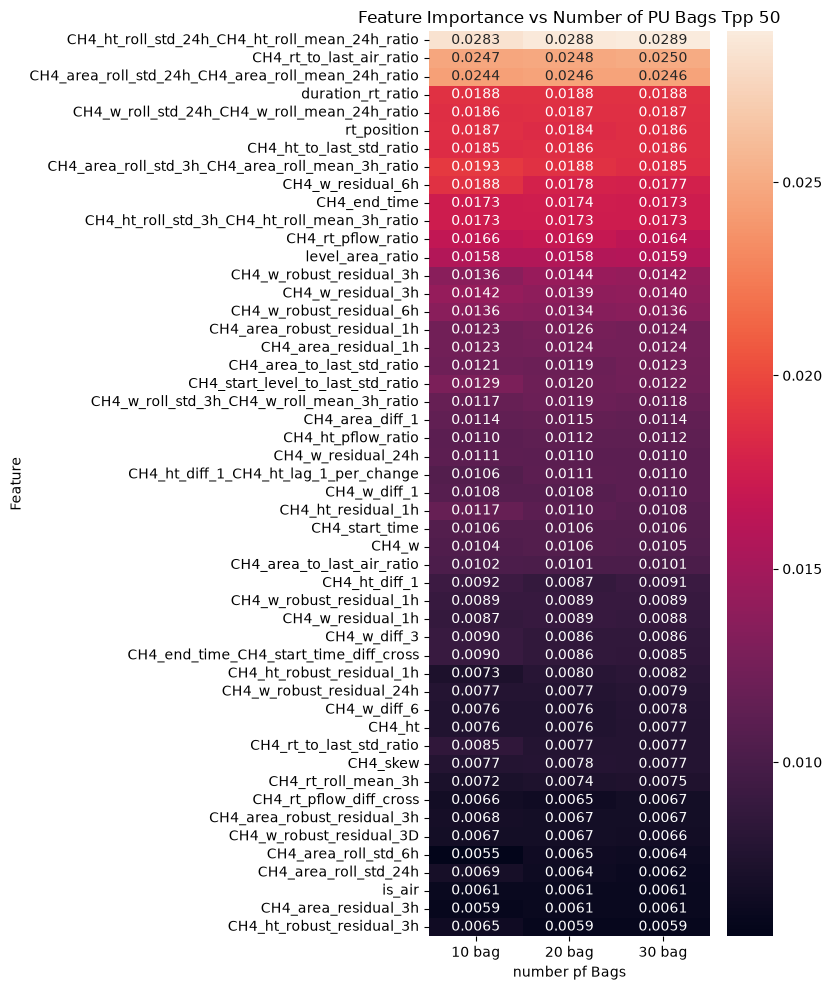

<Figure size 640x480 with 0 Axes>

In [12]:
top50 = importance_summary_30.head(50)["Feature"]
plot_data = importance_compare.loc[top50]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".4f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance vs Number of PU Bags Tpp 50")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp10_30_compare.png")

### coefficient of variation (CV)

In [13]:
cv_compare = pd.concat({
    "10 bag": importance_summary_10.set_index("Feature")["importance_cv percent"],
    "20 bag": importance_summary_20.set_index("Feature")["importance_cv percent"],
    "30 bag": importance_summary_30.set_index("Feature")["importance_cv percent"]
}, axis = 1)

cv_compare

,10 bag,20 bag,30 bag
Feature,,,
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,4.7970,5.9426,5.6230
CH4_rt_to_last_air_ratio,5.6817,5.2075,4.4341
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,5.4440,6.3461,6.6622
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,5.0554,5.8163,5.9906
CH4_w_residual_6h,19.5203,25.2046,25.3296
duration_rt_ratio,2.0085,1.8314,1.6857
rt_position,3.8718,5.7866,5.3117
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,10.8394,10.9127,9.6370
CH4_ht_to_last_std_ratio,2.5882,3.1683,3.3578


### Plot CV heatmap

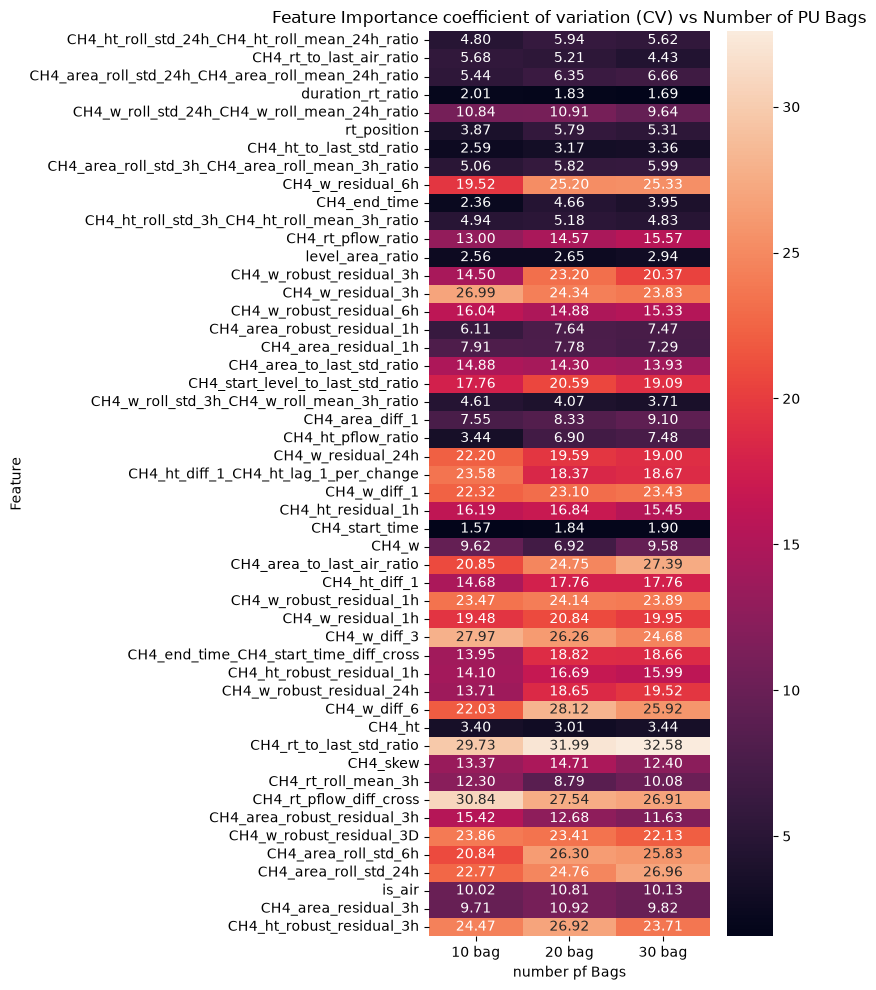

<Figure size 640x480 with 0 Axes>

In [15]:

plot_data = cv_compare.loc[top50]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".2f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance coefficient of variation (CV) vs Number of PU Bags")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp10_30__cv_compare.png")

### Rank

In [16]:
rank_compare = pd.concat({
    "10 bag": rank_10.set_index("Feature")["rank_mean"],
    "20 bag": rank_20.set_index("Feature")["rank_mean"],
    "30 bag": rank_30.set_index("Feature")["rank_mean"]
}, axis = 1)

rank_compare

,10 bag,20 bag,30 bag
Feature,,,
CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio,1.0,1.05,1.0667
CH4_rt_to_last_air_ratio,2.5,2.60,2.5333
CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio,2.8,2.65,2.6667
CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio,5.8,6.80,7.3667
duration_rt_ratio,6.4,6.40,6.2000
rt_position,6.9,7.40,6.6667
CH4_ht_to_last_std_ratio,7.2,7.05,7.0333
CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio,8.0,7.70,7.4667
CH4_w_residual_6h,8.8,10.55,10.9667


### Plot Rank heatmap

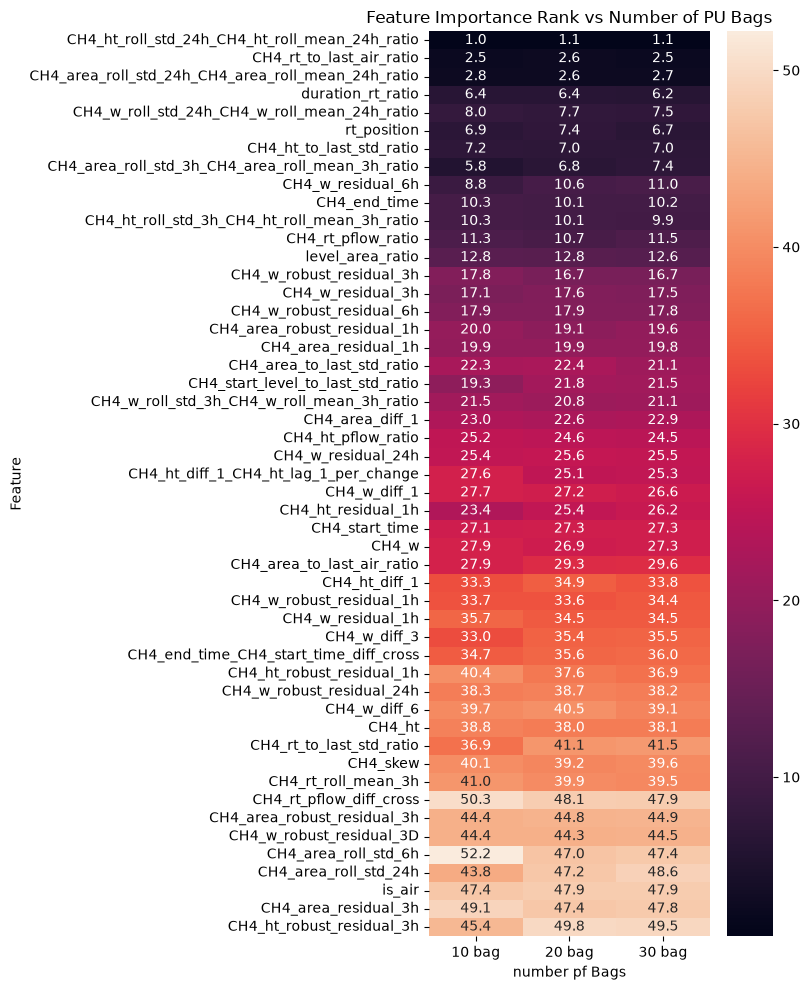

<Figure size 640x480 with 0 Axes>

In [17]:
plot_data = rank_compare.loc[top50]

plt.figure(figsize=(8, 10))

sns.heatmap(
    plot_data,
    annot=True,
    fmt=".1f"
)

plt.xlabel("number pf Bags")
plt.ylabel("Feature")
plt.title("Feature Importance Rank vs Number of PU Bags")
plt.tight_layout()
plt.show()

plt.savefig("img/Fea_imp5_30__rank_compare.png")

#### Compare results



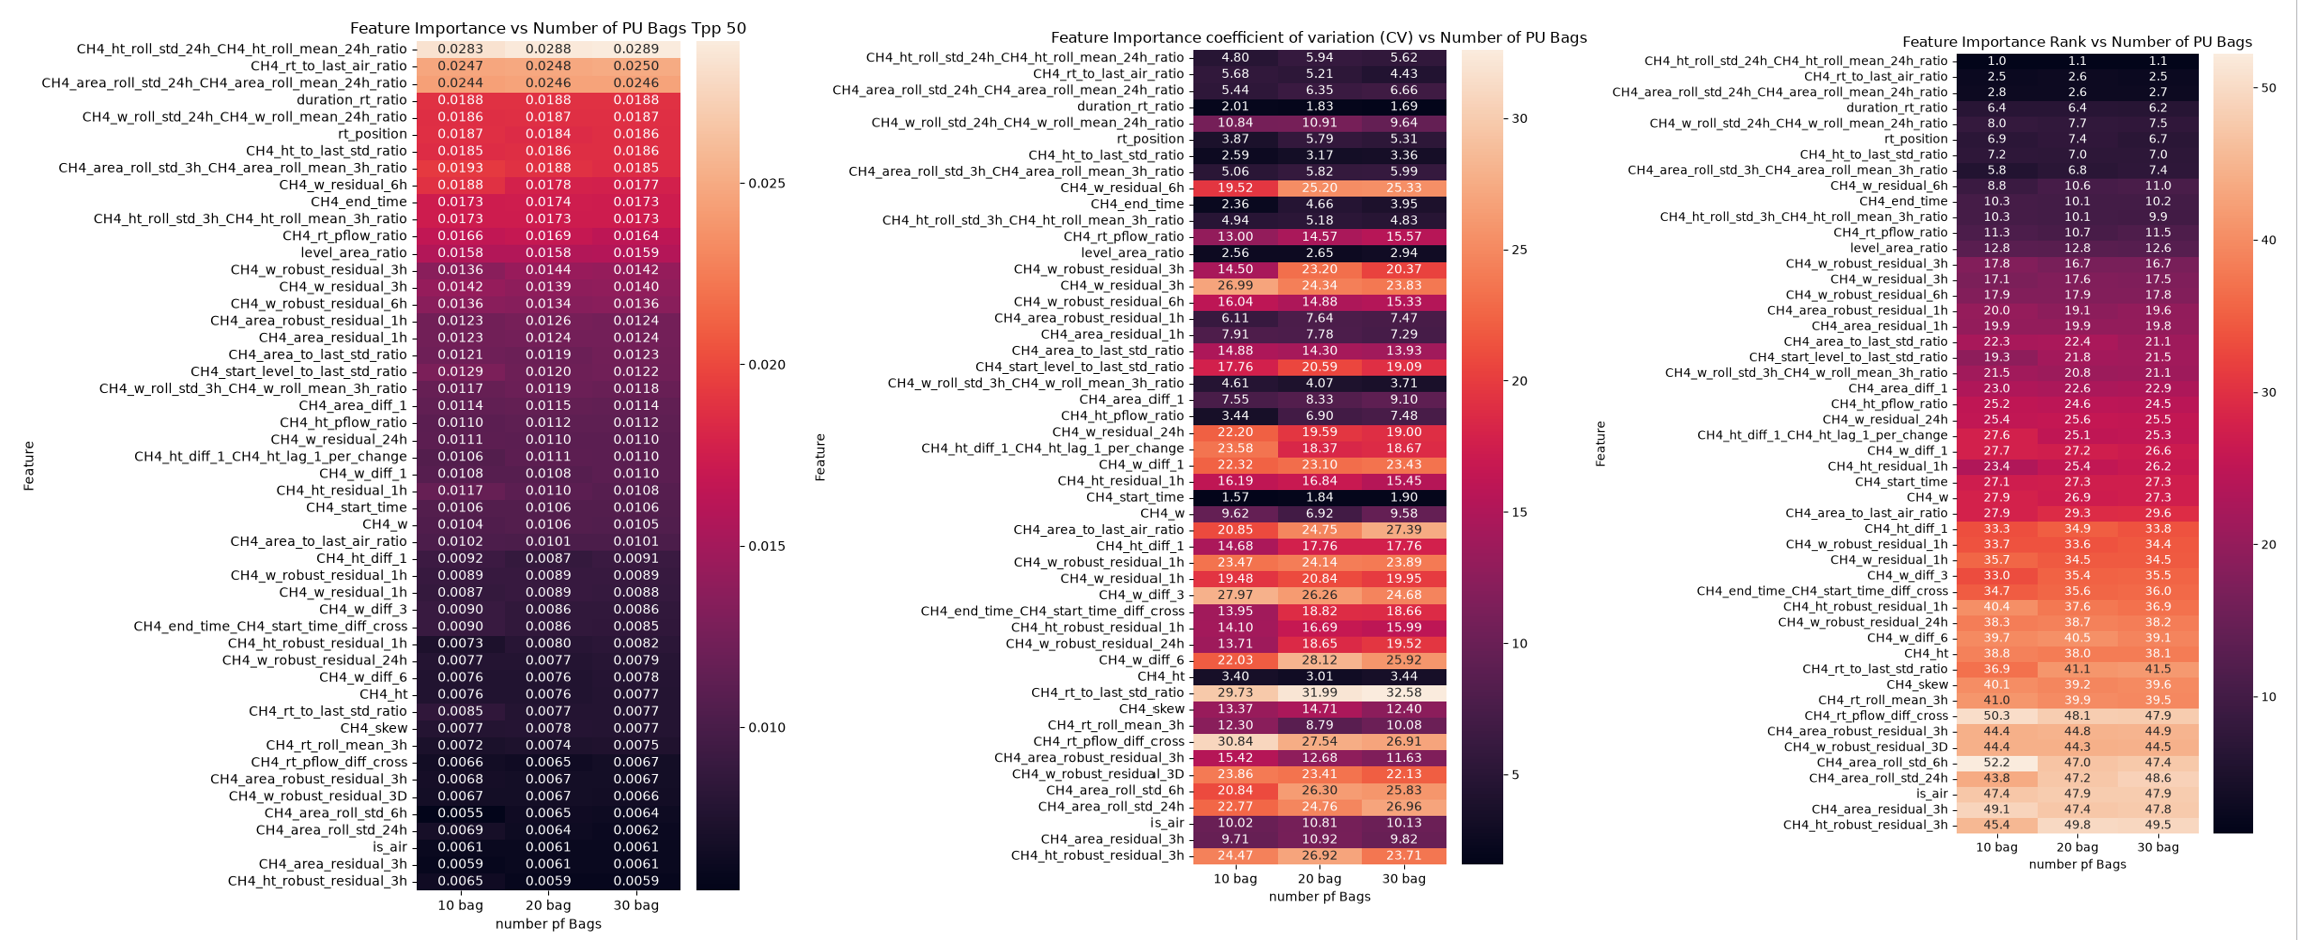

In [ ]:
# top 50' feature
top50.tolist()

['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'duration_rt_ratio',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'rt_position',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_residual_6h',
 'CH4_end_time',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_w_robust_residual_3h',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_area_diff_1',
 'CH4_ht_pflow_ratio',
 'CH4_w_residual_24h',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_w_diff_1',
 'CH4_ht_residual_1h',
 'CH4_start_time',
 'CH4_w',
 'CH4_area_to_last_air_ratio',
 'CH4_ht_diff_1',
 'CH4_w_robust_residual_1h',
 'CH4_w_residual_1h',
 'CH4_w_diff_3',
 'CH4_end_time_CH

In [ ]:
# Filter some feature first 

df_filter = pd.DataFrame({
    'importance':importance_compare['30 bag'],
    'cv': cv_compare['30 bag'],
    'rank':rank_compare['30 bag']
}).reset_index()


rule1_mask = ~((df_filter['rank'] > 50) & (df_filter['importance'] < 0.01)) # less important

rule2_mask = ~((df_filter['cv'] > 20.0) & (df_filter['rank'] > 50)) #unstable

df_selected = df_filter[rule1_mask & rule2_mask].sort_values("rank")
candidate_features = df_selected['Feature'].head(50).tolist()




In [21]:
candidate_features

['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'duration_rt_ratio',
 'rt_position',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_end_time',
 'CH4_w_residual_6h',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_w_robust_residual_3h',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_area_diff_1',
 'CH4_ht_pflow_ratio',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_w_residual_24h',
 'CH4_ht_residual_1h',
 'CH4_w_diff_1',
 'CH4_w',
 'CH4_start_time',
 'CH4_area_to_last_air_ratio',
 'CH4_ht_diff_1',
 'CH4_w_robust_residual_1h',
 'CH4_w_residual_1h',
 'CH4_w_diff_3',
 'CH4_end_time_CH

In [ ]:
len(candidate_features) # all top 50 feature exhibit stable and high importance

50

=================================================================================

### Plot PU-Bagging Feature Selection Learning Curve (PRC / PR-AUC)
***To determine the optimal number of features** 

=== Start ===
Number of Bag: 10
Positive: 18296
Unlabeled: 479128

 PU training data, Bag 1/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 2/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 3/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 4/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 5/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 6/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 7/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 8/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 9/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 10/10 Positive = 18296, Unlabeled = 18296
TOP K = 10 features | validation (PR-AUC): 0.4976
Number of Bag: 10
Positive: 18296
Unlabeled: 479128

 PU training data, Bag 1/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 2/10 Positive = 18296, Unlabeled = 18296

 PU training data, Bag 3/10 Positive = 18296, Unla

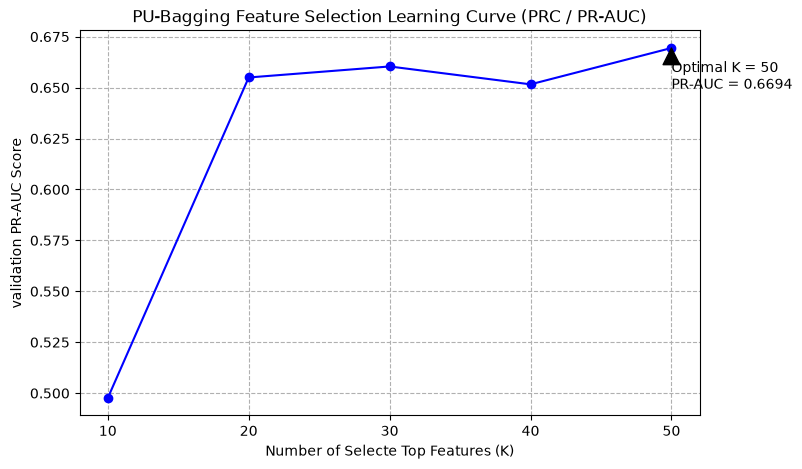

Final features and number: 50 
 ['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio', 'CH4_rt_to_last_air_ratio', 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio', 'duration_rt_ratio', 'rt_position', 'CH4_ht_to_last_std_ratio', 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio', 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio', 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio', 'CH4_end_time', 'CH4_w_residual_6h', 'CH4_rt_pflow_ratio', 'level_area_ratio', 'CH4_w_robust_residual_3h', 'CH4_w_residual_3h', 'CH4_w_robust_residual_6h', 'CH4_area_robust_residual_1h', 'CH4_area_residual_1h', 'CH4_area_to_last_std_ratio', 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio', 'CH4_start_level_to_last_std_ratio', 'CH4_area_diff_1', 'CH4_ht_pflow_ratio', 'CH4_ht_diff_1_CH4_ht_lag_1_per_change', 'CH4_w_residual_24h', 'CH4_ht_residual_1h', 'CH4_w_diff_1', 'CH4_w', 'CH4_start_time', 'CH4_area_to_last_air_ratio', 'CH4_ht_diff_1', 'CH4_w_robust_residual_1h', 'CH4_w_residual_1h', 'CH4_w_diff_3', 'CH4_end_time_CH4_

In [ ]:
from sklearn.metrics import average_precision_score
val_split_idx = int(len(X_train_final)*0.8)

#80% training
X_tr = X_train_final.iloc[:val_split_idx]
y_tr = y_train.iloc[:val_split_idx]

# 20% validation
X_val = X_train_final.iloc[val_split_idx:]
y_val = y_train.iloc[val_split_idx:]

# Number of features
k_candidates = np.arange(10, 60, 10)
k_list = [k for k in k_candidates if k <= len(candidate_features)]


val_prc_scores = []

print("=== Start ===")

for k in k_list:
    #Number of features for current iter
    sub_features = candidate_features[:k]
    # train model
    models, _, _ = bagging_rf(10, X_tr[sub_features], y_tr)

    # validate model
    val_preds = np.mean([m.predict_proba(X_val[sub_features])[:, 1] for m in models], axis=0)

    # Calculate prc_auc score
    prc_auc= average_precision_score(y_val, val_preds)
    val_prc_scores.append(prc_auc)

    print(f"TOP K = {k:2d} features | validation (PR-AUC): {prc_auc:.4f}")

best_idx = np.argmax(val_prc_scores)
best_k = k_list[best_idx]

best_features = candidate_features[:best_k]

#plotting
plt.figure(figsize=(8,5))
plt.plot(k_list, val_prc_scores, 'o-', color='blue', label='PR-AUC Score')


plt.annotate(
    f"Optimal K = {best_k}\nPR-AUC = {val_prc_scores[best_idx]:.4f}",
    xy = (best_k, val_prc_scores[best_idx]),
    xytext=(best_k, val_prc_scores[best_idx] - 0.02),
    arrowprops=dict(facecolor='black')
)


plt.title('PU-Bagging Feature Selection Learning Curve (PRC / PR-AUC)')
plt.xlabel("Number of Selecte Top Features (K)")
plt.ylabel("validation PR-AUC Score")
plt.xticks(k_list)
plt.grid(True, linestyle='--')
plt.show()
print(f'Final features and number:', best_k, "\n", best_features)

**Final Features**

In [24]:
best_features[:30]

['CH4_ht_roll_std_24h_CH4_ht_roll_mean_24h_ratio',
 'CH4_rt_to_last_air_ratio',
 'CH4_area_roll_std_24h_CH4_area_roll_mean_24h_ratio',
 'duration_rt_ratio',
 'rt_position',
 'CH4_ht_to_last_std_ratio',
 'CH4_area_roll_std_3h_CH4_area_roll_mean_3h_ratio',
 'CH4_w_roll_std_24h_CH4_w_roll_mean_24h_ratio',
 'CH4_ht_roll_std_3h_CH4_ht_roll_mean_3h_ratio',
 'CH4_end_time',
 'CH4_w_residual_6h',
 'CH4_rt_pflow_ratio',
 'level_area_ratio',
 'CH4_w_robust_residual_3h',
 'CH4_w_residual_3h',
 'CH4_w_robust_residual_6h',
 'CH4_area_robust_residual_1h',
 'CH4_area_residual_1h',
 'CH4_area_to_last_std_ratio',
 'CH4_w_roll_std_3h_CH4_w_roll_mean_3h_ratio',
 'CH4_start_level_to_last_std_ratio',
 'CH4_area_diff_1',
 'CH4_ht_pflow_ratio',
 'CH4_ht_diff_1_CH4_ht_lag_1_per_change',
 'CH4_w_residual_24h',
 'CH4_ht_residual_1h',
 'CH4_w_diff_1',
 'CH4_w',
 'CH4_start_time',
 'CH4_area_to_last_air_ratio']

==================================